# **Clasificación de Radiografías de Tórax con CNN**
##Proyecto 1 - Técnicas de Aprendizaje de Máquina

Juan David Ramirez y Juan Diego Carreño

1. Introducción y contexto del problema
2. Importación de datasets
3. Análisis Exploratorio de Datos (EDA)
4. Preprocesamiento de Imágenes
6. Diseño de la Red Neuronal
7. Entrenamiento y Evaluación del Modelo
8. Interpretación de Resultados
9. Conclusiones

##Introduccion y contexto

El análisis de radiografías de tórax es una herramienta fundamental en el diagnóstico de enfermedades respiratorias como la neumonía y el COVID-19. Sin embargo, la interpretación clínica de estas imágenes puede verse afectada por la subjetividad humana, la variabilidad entre especialistas y la alta demanda de evaluación en entornos hospitalarios. Estas limitaciones motivan el desarrollo de herramientas computacionales capaces de asistir el proceso diagnóstico mediante el reconocimiento automático de patrones en imágenes médicas.

En este proyecto se aborda el problema de clasificación automática de radiografías de tórax utilizando redes neuronales convolucionales (CNN). El objetivo es entrenar un modelo de aprendizaje profundo capaz de distinguir entre imágenes de pacientes sanos y pacientes con patologías respiratorias, específicamente neumonía y COVID-19. Este enfoque aprovecha la capacidad de las CNN para extraer características visuales complejas y aprender representaciones jerárquicas directamente a partir de los datos.

El flujo de trabajo desarrollado incluye análisis exploratorio del conjunto de datos, preprocesamiento de imágenes, diseño de la arquitectura de la red neuronal, entrenamiento del modelo y evaluación de su desempeño mediante métricas de clasificación. Además, se analizan los resultados obtenidos con el fin de identificar fortalezas, limitaciones y posibles mejoras del sistema propuesto.

##Importación de datasets

En esta etapa se realiza la descarga, verificación y organización inicial de los conjuntos de datos que serán utilizados para el entrenamiento del modelo de clasificación de radiografías de tórax. El propósito es garantizar la integridad de los datos, su correcta accesibilidad desde el entorno de ejecución y su compatibilidad con el flujo de procesamiento posterior.

### Fuentes de datos

El proyecto utiliza dos conjuntos de datos públicos de radiografías de tórax obtenidos desde Kaggle mediante API:

*  Dataset de radiografías asociadas a COVID-19
*  Dataset de radiografías de neumonía pediátrica

La combinación de ambas fuentes permite construir un problema de clasificación multiclase clínicamente relevante que incluye pacientes sanos y pacientes con patologías respiratorias.

###Descarga y verificación de los datasets

Los datasets se descargan automáticamente mediante la API de Kaggle. Posteriormente, se inspecciona la estructura de carpetas para verificar la presencia de archivos de imagen y confirmar la correcta organización de las categorías clínicas.

In [1]:
import os
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image
import kagglehub

In [2]:
covid_path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")
pneumonia_path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("COVID19 Radiography DB path:", covid_path)
print("Chest X-Ray Pneumonia path:", pneumonia_path)

Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
COVID19 Radiography DB path: /kaggle/input/covid19-radiography-database
Chest X-Ray Pneumonia path: /kaggle/input/chest-xray-pneumonia


In [3]:
def check_folders(path):
    for root, dirs, files in os.walk(path):
        if files:
            print(f"Carpeta: {os.path.basename(root)} | Imágenes: {len(files)}")

print("--- Verificando Dataset COVID-19 ---")
check_folders(covid_path) # Ajusta 'path_covid' a la variable de tu ruta

print("\n--- Verificando Dataset Neumonía ---")
check_folders(pneumonia_path) # Ajusta 'path_pneumonia' a la variable de tu ruta

--- Verificando Dataset COVID-19 ---
Carpeta: COVID-19_Radiography_Dataset | Imágenes: 5
Carpeta: images | Imágenes: 10192
Carpeta: masks | Imágenes: 10192
Carpeta: images | Imágenes: 6012
Carpeta: masks | Imágenes: 6012
Carpeta: images | Imágenes: 1345
Carpeta: masks | Imágenes: 1345
Carpeta: images | Imágenes: 3616
Carpeta: masks | Imágenes: 3616

--- Verificando Dataset Neumonía ---
Carpeta: chest_xray | Imágenes: 1
Carpeta: val | Imágenes: 1
Carpeta: PNEUMONIA | Imágenes: 9
Carpeta: NORMAL | Imágenes: 9
Carpeta: test | Imágenes: 1
Carpeta: PNEUMONIA | Imágenes: 390
Carpeta: NORMAL | Imágenes: 234
Carpeta: train | Imágenes: 1
Carpeta: PNEUMONIA | Imágenes: 3876
Carpeta: NORMAL | Imágenes: 1342
Carpeta: __MACOSX | Imágenes: 1
Carpeta: chest_xray | Imágenes: 3
Carpeta: val | Imágenes: 1
Carpeta: PNEUMONIA | Imágenes: 9
Carpeta: NORMAL | Imágenes: 9
Carpeta: test | Imágenes: 3
Carpeta: PNEUMONIA | Imágenes: 390
Carpeta: NORMAL | Imágenes: 234
Carpeta: train | Imágenes: 3
Carpeta: PNEUM

### Estructuración de etiquetas

Debido a la heterogeneidad entre los datasets originales, se definió una estructura de etiquetas unificada compuesta por tres clases:



*   Normal
*   Neumonía
*   COVID-19

En el dataset de radiografías COVID-19 se incluye la categoría Lung Opacity, que representa opacidades pulmonares compatibles con procesos infecciosos o inflamatorios, pero no distingue entre etiologías específicas. Por otro lado, el dataset de neumonía pediátrica diferencia entre neumonía viral y bacteriana, mientras que el dataset de COVID-19 no especifica el tipo de infección pulmonar asociada.

Con el fin de mantener coherencia clínica entre las fuentes de datos y evitar inconsistencias semánticas entre etiquetas, todas las manifestaciones de infección pulmonar no COVID (incluyendo neumonía viral, neumonía bacteriana y opacidades pulmonares) fueron agrupadas en una única categoría denominada Neumonía.

Esta decisión permite:


*   Reducir la ambigüedad entre clases con alta similitud radiológica
*   Homogeneizar las etiquetas entre datasets de distinta procedenciaa


Facilitar el aprendizaje del modelo al enfocarlo en la discriminación entre pulmón sano, infección pulmonar general y COVID-19

### Construcción del conjunto de datos unificado

Se construyó un DataFrame que almacena para cada imagen:



*   Ruta del archiv
*   Etiqueta clínica final
*   Fuente de procedencia
*   División original del dataset (cuando está disponible)

Esta estructura permite realizar análisis exploratorio, partición de datos y entrenamiento del modelo de forma consistente.

In [ ]:
import os
import pandas as pd

# Rutas base
IMG_EXT = (".png", ".jpg", ".jpeg")
covid_base = os.path.join(covid_path, "COVID-19_Radiography_Dataset")

# ✅ Nombres reales de carpetas (según tu ls)
covid_dirs = {
    "COVID": "COVID",
    "Viral Pneumonia": "Neumonia",
    "Lung_Opacity": "Neumonia",
    "Normal": "Normal"
}

covid_records = []

for folder_name, final_label in covid_dirs.items():
    img_dir = os.path.join(covid_base, folder_name, "images")
    if os.path.exists(img_dir):
        for file in os.listdir(img_dir):
            if file.lower().endswith(IMG_EXT):
                covid_records.append({
                    "filepath": os.path.join(img_dir, file),
                    "label": final_label,
                    "source": "COVID_Radiography"
                })

# Dataset Neumonía (pediátrico)
pneu_base = os.path.join(pneumonia_path, "chest_xray")
splits = ["train", "val", "test"]

pneu_records = []

for split in splits:
    split_dir = os.path.join(pneu_base, split)
    if os.path.exists(split_dir):
        for class_folder in os.listdir(split_dir):
            class_dir = os.path.join(split_dir, class_folder)
            if os.path.isdir(class_dir):
                if class_folder.upper() == "NORMAL":
                    final_label = "Normal"
                elif class_folder.upper() == "PNEUMONIA":
                    final_label = "Neumonia"
                else:
                    continue

                for file in os.listdir(class_dir):
                    if file.lower().endswith(IMG_EXT):
                        pneu_records.append({
                            "filepath": os.path.join(class_dir, file),
                            "label": final_label,
                            "source": "Pediatric_Pneumonia",
                            "split": split
                        })

# Unificar
df_covid = pd.DataFrame(covid_records)
df_pneu = pd.DataFrame(pneu_records)

df_combined = pd.concat([df_covid, df_pneu], ignore_index=True)

print("Total imágenes combinadas:", len(df_combined))

print("\nDistribución por clase:")
print(df_combined["label"].value_counts())

print("\nDistribución por fuente:")
print(df_combined["source"].value_counts())

print("\nEjemplo filas:")
print(df_combined.sample(5, random_state=7))


Total imágenes combinadas: 27021

Distribución por clase:
label
Normal      11775
Neumonia    11630
COVID        3616
Name: count, dtype: int64

Distribución por fuente:
source
COVID_Radiography      21165
Pediatric_Pneumonia     5856
Name: count, dtype: int64

Ejemplo filas:
                                                filepath     label  \
2506   /kaggle/input/covid19-radiography-database/COV...     COVID   
23782  /kaggle/input/chest-xray-pneumonia/chest_xray/...  Neumonia   
13473  /kaggle/input/covid19-radiography-database/COV...    Normal   
7695   /kaggle/input/covid19-radiography-database/COV...  Neumonia   
21837  /kaggle/input/chest-xray-pneumonia/chest_xray/...  Neumonia   

                    source  split  
2506     COVID_Radiography    NaN  
23782  Pediatric_Pneumonia  train  
13473    COVID_Radiography    NaN  
7695     COVID_Radiography    NaN  
21837  Pediatric_Pneumonia  train  


###Resultado de la importación

La integración de los datasets produjo un conjunto de datos unificado que será utilizado en las etapas posteriores del proyecto.

Los datasets fueron descargados, verificados y estructurados exitosamente en un formato unificado que permite su uso eficiente en las fases de análisis exploratorio, preprocesamiento y entrenamiento del modelo.

##3. Análisis Exploratorio de Datos (EDA)

El análisis exploratorio tiene como propósito caracterizar la distribución, estructura técnica y propiedades estadísticas del conjunto de radiografías de tórax, así como identificar posibles sesgos que puedan influir en el entrenamiento y la generalización del modelo de clasificación.

###Fase 1 - Distribución y Estructura

In [ ]:

color_map = {
    'Normal': '#2A9D8F',     # Verde azulado (Equilibrio/Salud)
    'Neumonia': '#264653',   # Azul oscuro (Condición clínica)
    'COVID': '#E9C46A'       # Dorado/Amarillo (Alerta/Emergencia)
}

/tmp/ipython-input-2485835545.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=current_labels, y=stats.values, palette=current_colors)


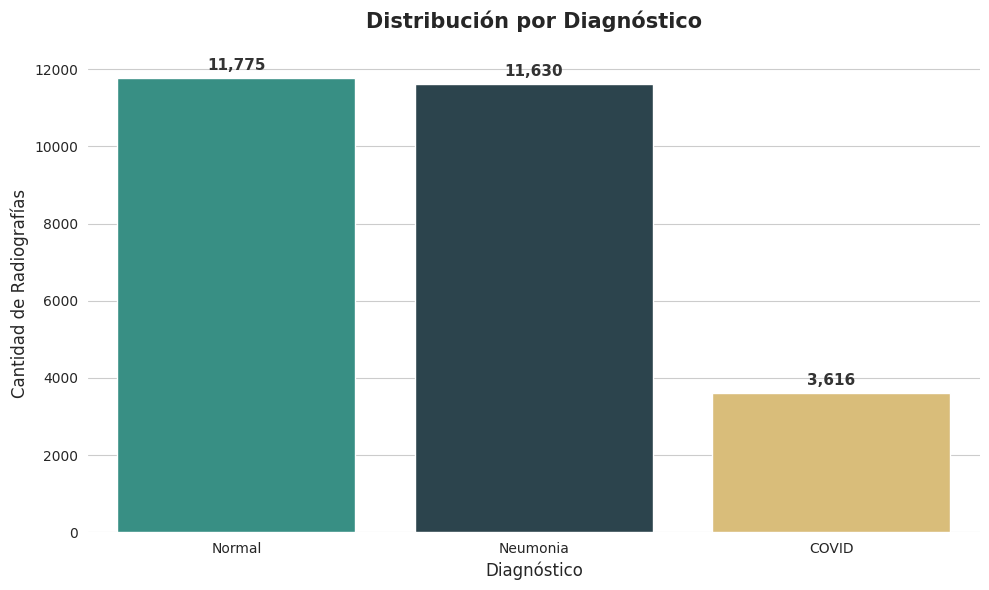

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Aseguramos que 'stats' exista (basado en tu DataFrame df_combined)
stats = df_combined['label'].value_counts()

# 2. Definición de la Paleta Profesional (Copia exacta para consistencia)
color_map = {
    'Normal': '#2A9D8F',     # Verde azulado
    'Neumonia': '#264653',   # Azul oscuro
    'COVID': '#E9C46A'       # Dorado/Amarillo
}

# 3. Preparación de datos para el gráfico
current_labels = stats.index.tolist()
current_colors = [color_map.get(label, '#808080') for label in current_labels]

# 4. Creación del Gráfico de Barras
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Dibujar barras
ax = sns.barplot(x=current_labels, y=stats.values, palette=current_colors)

# Añadir etiquetas de valor sobre las barras (con formato de miles)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=11, fontweight='bold', color='#333333')

# Títulos y Estética
plt.title('Distribución por Diagnóstico', fontsize=15, pad=20, fontweight='bold')
plt.ylabel('Cantidad de Radiografías', fontsize=12)
plt.xlabel('Diagnóstico', fontsize=12)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

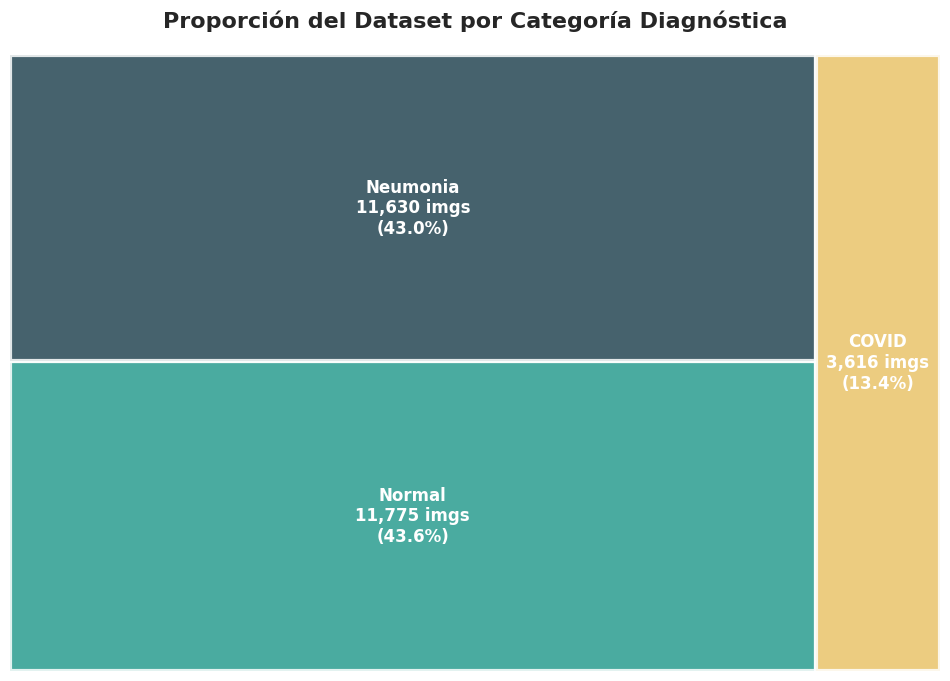

In [ ]:
# 1. Instalación del módulo necesario
!pip install squarify -q

import matplotlib.pyplot as plt
import squarify

# 2. Definición de datos (Consolidados de tus pasos anteriores)
labels = ['Normal', 'Neumonia', 'COVID']
sizes = [11775, 11630, 3616]

# 3. Diccionario de colores profesional (Consistente con el gráfico de barras)
color_map = {
    'Normal': '#2A9D8F',     # Verde azulado
    'Neumonia': '#264653',   # Azul oscuro
    'COVID': '#E9C46A'       # Dorado/Amarillo
}
colors_tree = [color_map[l] for l in labels]

# 4. Preparar etiquetas con formato (Nombre, Cantidad y Porcentaje)
total = sum(sizes)
labels_perc = [f'{l}\n{s:,} imgs\n({(s/total)*100:.1f}%)' for l, s in zip(labels, sizes)]

# 5. Crear el gráfico Treemap
plt.figure(figsize=(12, 8))

squarify.plot(
    sizes=sizes,
    label=labels_perc,
    color=colors_tree,
    alpha=0.85,
    edgecolor="white",
    linewidth=3,
    text_kwargs={'fontsize': 12, 'weight': 'bold', 'color': 'white'}
)

plt.title('Proporción del Dataset por Categoría Diagnóstica', fontsize=16, pad=20, fontweight='bold')
plt.axis('off')

# Guardar y mostrar
plt.savefig('treemap_clases_final.png', dpi=300, bbox_inches='tight')
plt.show()

El conjunto de datos consolidado contiene 27,021 radiografías distribuidas en tres categorías clínicas. Las clases Normal y Neumonía presentan proporciones prácticamente equivalentes, mientras que la clase COVID-19 constituye la fracción minoritaria del conjunto.

La presencia de una clase de interés clínico con menor representación implica que la evaluación del modelo no puede basarse únicamente en la exactitud global. En consecuencia, se priorizarán métricas sensibles al desbalance, como recall y F1-score por clase, especialmente para la detección de COVID-19.

Desde el punto de vista técnico, el dataset presenta alta heterogeneidad estructural, con resoluciones que oscilan entre 299×177 y 2637×2399 píxeles, coexistencia de formatos PNG y JPEG, y presencia de imágenes tanto en escala de grises como en RGB. Esta variabilidad justifica la necesidad de un pipeline de normalización que estandarice tamaño, número de canales y rango de intensidades antes del entrenamiento.

### Fase 2- Calidad Visual

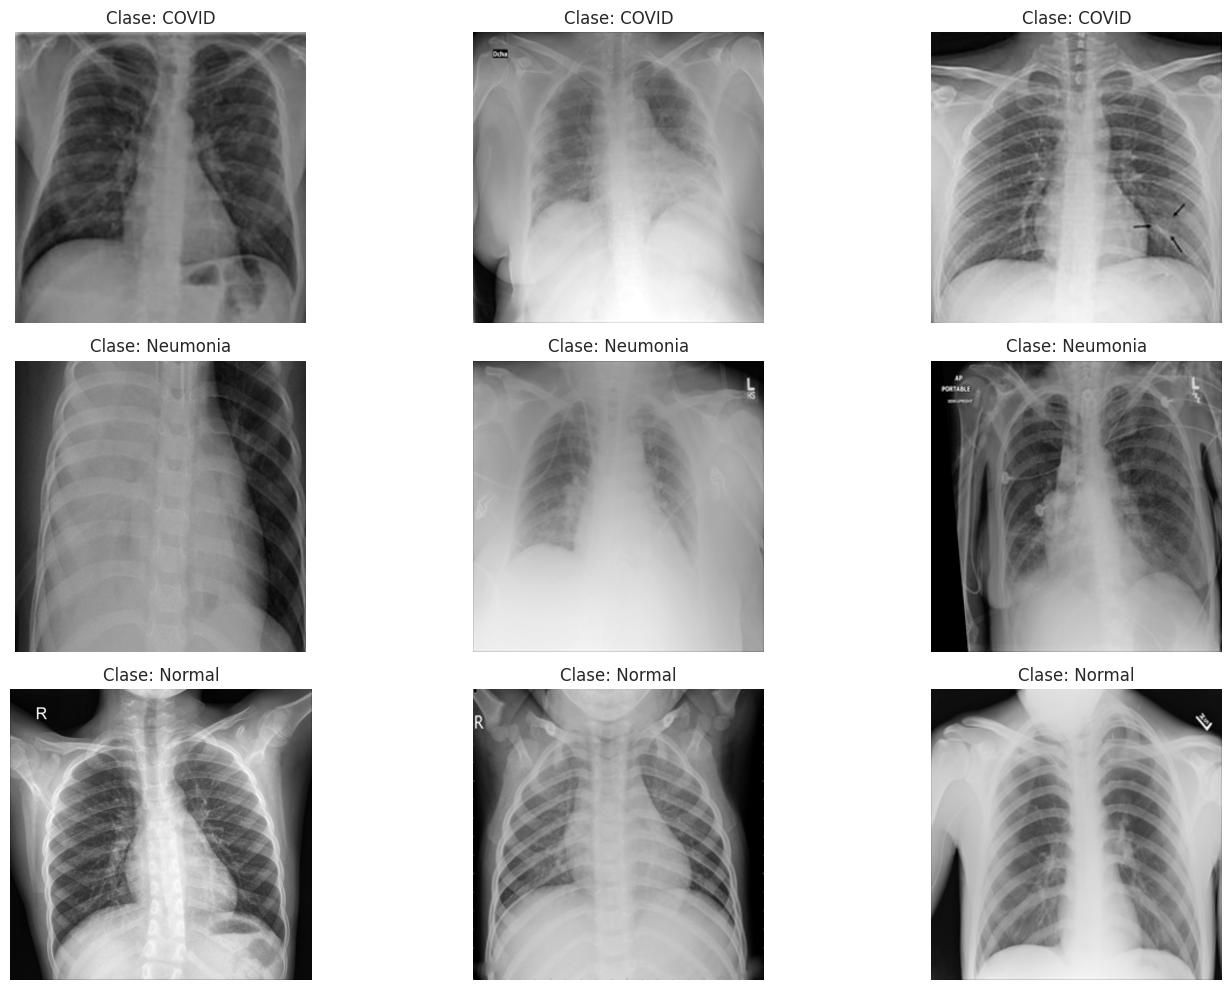

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_samples_per_class(df, n=3):
    classes = df['label'].unique()
    fig, axes = plt.subplots(len(classes), n, figsize=(15, 10))

    for i, cls in enumerate(classes):
        sample_paths = df[df['label'] == cls]['filepath'].sample(n, random_state=42).values
        for j, path in enumerate(sample_paths):
            img = Image.open(path).convert('RGB')
            axes[i, j].imshow(img)
            axes[i, j].set_title(f"Clase: {cls}")
            axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()

plot_samples_per_class(df_combined)

La inspección visual de muestras aleatorias permite observar la variabilidad morfológica entre clases y dentro de cada categoría diagnóstica. Las imágenes muestran diferencias en contraste, posicionamiento del paciente, campo de visión y artefactos de adquisición, lo que sugiere que el modelo deberá aprender patrones radiológicos robustos frente a variaciones técnicas.

Las imágenes serán redimensionadas a 224×224 píxeles durante el preprocesamiento para garantizar consistencia espacial en la entrada del modelo.

###Fase 3 — Estadísticas de intensidad

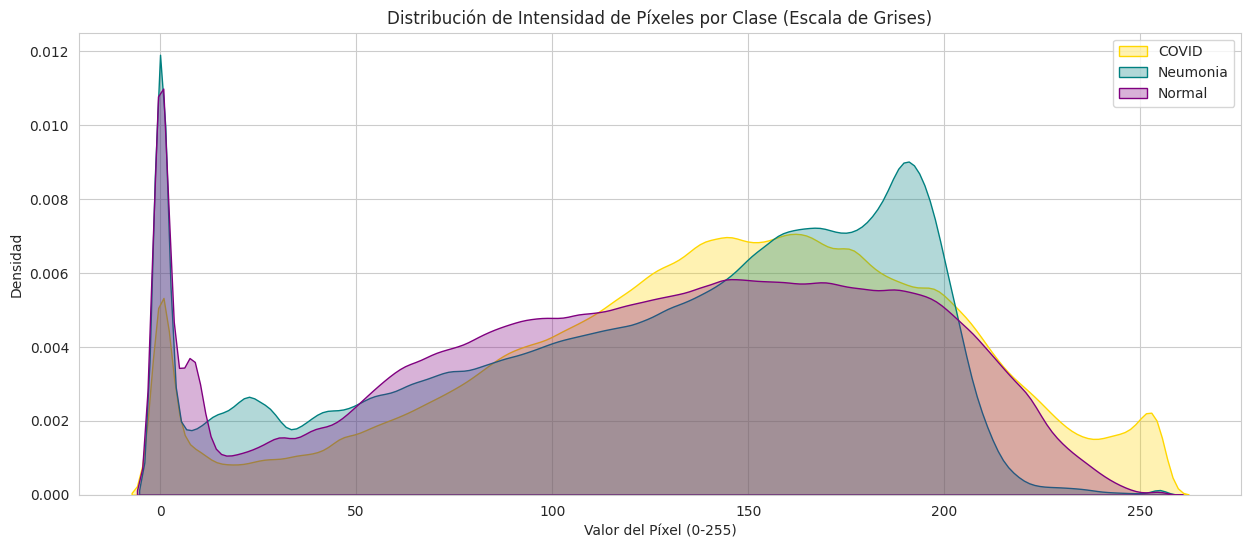

In [ ]:
def plot_intensity_histograms(df):
    plt.figure(figsize=(15, 6))
    colors = {'Normal': 'purple', 'Neumonia': 'teal', 'COVID': 'gold'}

    for cls in df['label'].unique():
        # Tomar una muestra para agilizar el cálculo
        sample_paths = df[df['label'] == cls]['filepath'].sample(100, random_state=42)
        pixel_values = []

        for path in sample_paths:
            img = Image.open(path).convert('L') # Convertir a escala de grises
            pixel_values.extend(np.array(img).flatten())

        sns.kdeplot(pixel_values, label=cls, color=colors[cls], fill=True, alpha=0.3)

    plt.title('Distribución de Intensidad de Píxeles por Clase (Escala de Grises)')
    plt.xlabel('Valor del Píxel (0-255)')
    plt.ylabel('Densidad')
    plt.legend()
    plt.show()

plot_intensity_histograms(df_combined)

El análisis de distribuciones de intensidad en escala de grises evidencia un alto grado de solapamiento entre las tres clases diagnósticas. No se observan desplazamientos sistemáticos que indiquen un sesgo global de brillo entre categorías.

Aunque existen diferencias leves en la luminancia promedio entre clases, su magnitud es pequeña en relación con la variabilidad intra-clase. Esto sugiere que la discriminación entre categorías no puede basarse únicamente en propiedades globales de intensidad, sino que dependerá de la identificación de patrones espaciales y morfológicos complejos.

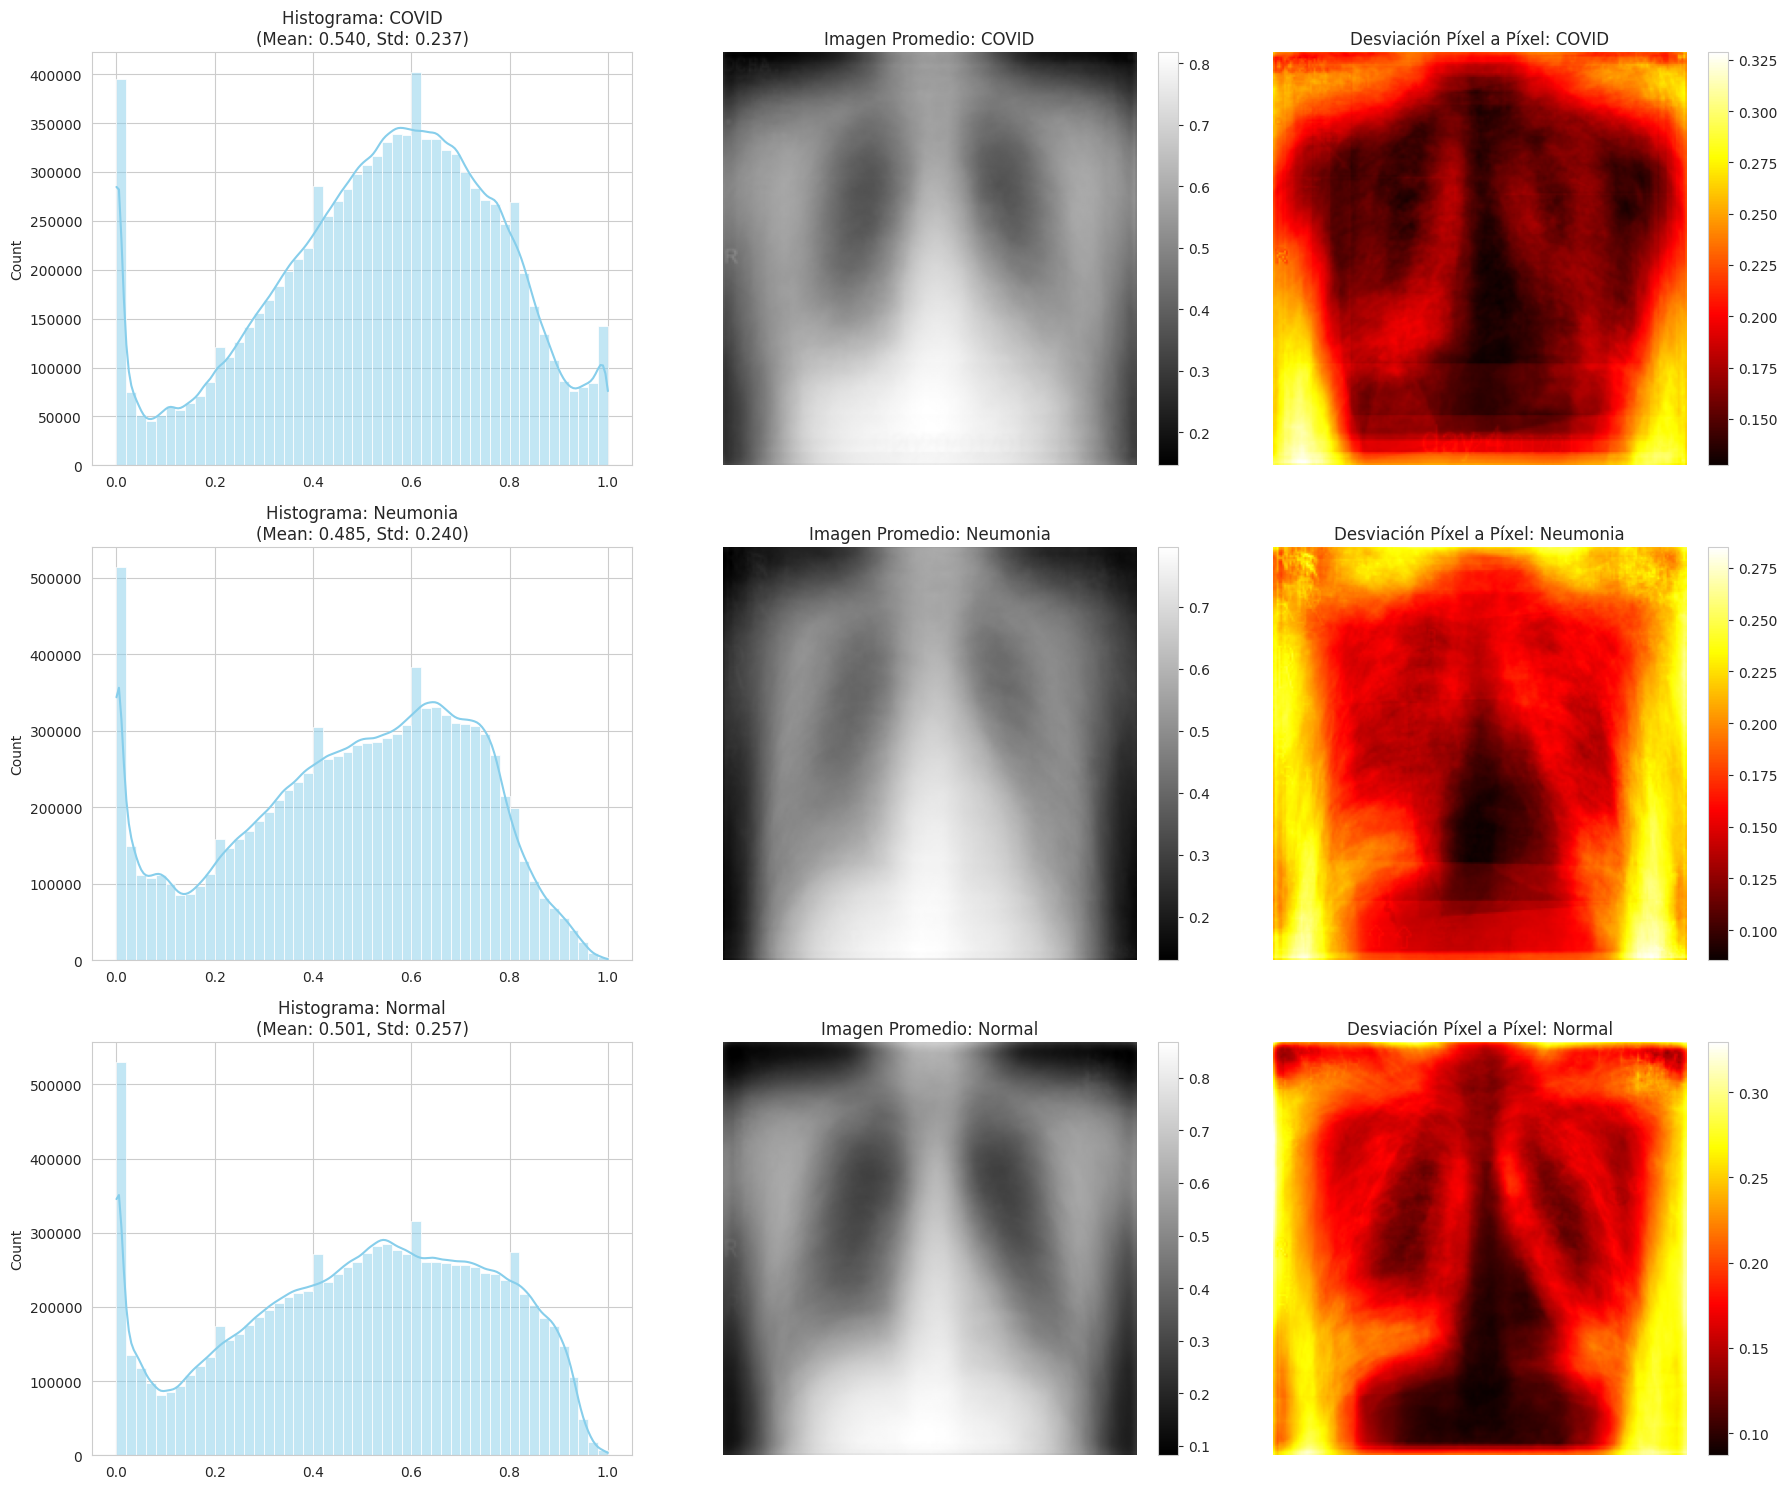


REPORTE TÉCNICO DE INTENSIDAD:
- COVID: Brillo promedio (Media) = 0.5397 | Contraste (Std) = 0.2367
- Neumonia: Brillo promedio (Media) = 0.4850 | Contraste (Std) = 0.2400
- Normal: Brillo promedio (Media) = 0.5006 | Contraste (Std) = 0.2569


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image

# ==========================================
# FASE 4: ESTADÍSTICAS DE INTENSIDAD Y VARIABILIDAD
# ==========================================

def perform_intensity_analysis(df, target_size=(224, 224), sample_size=200):
    stats_summary = {}
    classes = df['label'].unique()

    # Configuración de visualización
    fig, axes = plt.subplots(len(classes), 3, figsize=(18, 5 * len(classes)))

    for i, cls in enumerate(classes):
        # 1. Muestreo y Preprocesamiento básico (Redimensionamiento obligatorio)
        paths = df[df['label'] == cls]['filepath'].sample(min(len(df[df['label']==cls]), sample_size), random_state=42).values
        images = []

        for p in paths:
            # Convertimos a escala de grises para análisis de intensidad pura
            img = Image.open(p).convert('L').resize(target_size)
            images.append(np.array(img) / 255.0) # Normalización a [0, 1]

        images_array = np.array(images)

        # 2. Cálculo de Media y Desviación Estándar (Global de la clase)
        mean_val = np.mean(images_array)
        std_val = np.std(images_array)
        stats_summary[cls] = {'mean': mean_val, 'std': std_val}

        # 3. Análisis de Variabilidad Intra-clase (Imagen Promedio vs Desviación)
        avg_img = np.mean(images_array, axis=0)
        std_img = np.std(images_array, axis=0)

        # --- Visualizaciones ---

        # Columna 1: Histograma de Intensidades
        sns.histplot(images_array.flatten(), bins=50, kde=True, ax=axes[i, 0], color='skyblue')
        axes[i, 0].set_title(f'Histograma: {cls}\n(Mean: {mean_val:.3f}, Std: {std_val:.3f})')

        # Columna 2: Imagen Promedio (Patrón común)
        im1 = axes[i, 1].imshow(avg_img, cmap='gray')
        axes[i, 1].set_title(f'Imagen Promedio: {cls}')
        plt.colorbar(im1, ax=axes[i, 1], fraction=0.046, pad=0.04)
        axes[i, 1].axis('off')

        # Columna 3: Variabilidad Píxel a Píxel (Zonas de mayor cambio)
        im2 = axes[i, 2].imshow(std_img, cmap='hot')
        axes[i, 2].set_title(f'Desviación Píxel a Píxel: {cls}')
        plt.colorbar(im2, ax=axes[i, 2], fraction=0.046, pad=0.04)
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

    return stats_summary

# Ejecución del análisis
clase_stats = perform_intensity_analysis(df_combined)

# Imprimir reporte técnico de Phase 4
print("\nREPORTE TÉCNICO DE INTENSIDAD:")
for cls, s in clase_stats.items():
    print(f"- {cls}: Brillo promedio (Media) = {s['mean']:.4f} | Contraste (Std) = {s['std']:.4f}")

El análisis cuantitativo muestra que las diferencias de brillo promedio entre clases son moderadas y no superan la variabilidad interna de cada categoría. Asimismo, los mapas de desviación píxel a píxel revelan que la mayor variabilidad espacial se concentra en regiones pulmonares, lo que indica que estas áreas contienen la mayor diversidad de patrones radiológicos relevantes.

Estos resultados refuerzan la necesidad de normalización de intensidades y validan el uso de redes convolucionales como mecanismo adecuado para capturar estructuras espaciales complejas.

###Fase 5 Sesgos

Se identifican tres fuentes principales de sesgo estructural en el conjunto de datos:

Sesgo de definición de etiquetas
La clase Neumonía agrupa múltiples etiologías pulmonares con características radiológicas potencialmente distintas, lo que introduce heterogeneidad semántica dentro de la categoría.

Sesgo de dominio
Los datasets provienen de instituciones y condiciones de adquisición diferentes, lo que puede introducir patrones técnicos no relacionados con la patología.

Sesgo demográfico
La integración de radiografías pediátricas con imágenes de población adulta introduce diferencias anatómicas que podrían ser aprendidas por el modelo como señales discriminativas no clínicas.

Estos factores constituyen limitaciones estructurales que deben considerarse al interpretar el desempeño del modelo y su capacidad de generalización.

### Fase 6 Conclusiones del análisis exploratorio

El conjunto de datos presenta tamaño adecuado para entrenamiento profundo.

Existe desbalance moderado en la clase COVID-19.

Se confirma heterogeneidad técnica significativa entre imágenes.

No se detectan separaciones claras entre clases basadas solo en intensidad global.

Se identifican sesgos estructurales relevantes para la generalización.

##4. Preprocesamiento de Imágenes

El preprocesamiento tiene como finalidad transformar las radiografías originales en un formato homogéneo y compatible con el modelo de aprendizaje profundo, reduciendo variaciones técnicas no relacionadas con la patología y garantizando estabilidad durante el entrenamiento.

Las decisiones de diseño se fundamentan directamente en los hallazgos del análisis exploratorio, particularmente la heterogeneidad en resolución, formato y distribución de intensidades observada en el conjunto de datos.

###1- Estandarización de Entradas

Todas las imágenes son transformadas a un formato común con el fin de garantizar consistencia en la representación de los datos de entrada.

Transformaciones aplicadas:


*   Redimensionamiento a 224×224 píxeles
*   Conversión a escala de grises para eliminar variabilidad cromática irrelevante
*   Replicación a tres canales para compatibilidad con arquitecturas CNN estándar
*   Interpolación bilineal para preservar continuidad estructural


La elección de resolución 224×224 responde a estándares ampliamente utilizados en modelos de visión por computador y permite un balance adecuado entre costo computacional y preservación de información anatómica.

In [ ]:
import tensorflow as tf

# Configuración técnica basada en el análisis previo
IMG_SIZE = (224, 224)

def load_and_preprocess_image(path, label):
    # 1. Lectura y decodificación transparente de formatos (PNG/JPEG)
    image = tf.io.read_file(path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)

    # 2. Conversión a escala de grises (Unificar canales)
    # Aunque se carguen 3, forzamos la luminancia para evitar sesgos de color
    image = tf.image.rgb_to_grayscale(image)

    # 3. Redimensionamiento uniforme (Unificar tamaño)
    # Usamos interpolación bilineal para suavizar el re-escalado de RX
    image = tf.image.resize(image, IMG_SIZE)

    # Replicamos a 3 canales para cumplir con la arquitectura estándar de Keras
    image = tf.image.grayscale_to_rgb(image)

    return image, label

# Ejemplo de visualización de la estandarización
print(f"Tamaño unificado definido: {IMG_SIZE}")
print("Canales unificados: 3 (Grayscale replicado)")

Tamaño unificado definido: (224, 224)
Canales unificados: 3 (Grayscale replicado)


###02- Normalización de intensidades (brillo/contraste)

Las imágenes son escaladas al rango [0, 1] mediante normalización por el valor máximo de intensidad.

Esta transformación:



*   Reduce el impacto de variaciones globales de luminancia
*   Mejora la estabilidad numérica durante el entrenamiento
*   Facilita la convergencia del optimizado



No se aplicó estandarización z-score en esta etapa para preservar interpretabilidad visual durante la validación inicial del pipeline.

In [ ]:
import tensorflow as tf

def normalize_intensities(image, label):
    # 1. Normalización a rango [0, 1]
    # Dividimos por 255.0 para asegurar precisión de punto flotante (float32)
    image = tf.cast(image, tf.float32) / 255.0

    # 2. Nota técnica: No aplicamos estandarización Z-score (Media=0, Std=1)
    # por ahora para mantener la interpretabilidad visual durante el debug,
    # pero el escalado a [0, 1] ya mitiga el impacto de la luminancia global.

    return image, label

# Ejemplo de flujo integrado (Paso 1 + Paso 2)
def preprocess_pipeline(path, label):
    # Paso 1: Estandarización (Tamaño y Canales)
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize_with_pad(img, 224, 224)
    img = tf.image.rgb_to_grayscale(img)
    img = tf.image.grayscale_to_rgb(img)

    # Paso 2: Normalización
    img, label = normalize_intensities(img, label)

    return img, label

###03- Control de calidad mínimo

Se implementó un procedimiento de validación para detectar archivos corruptos, vacíos o no decodificables antes del entrenamiento.

El control verifica:


*   Correcta decodificación del archivo
*   Dimensiones válidas de la imagen
*   Compatibilidad con el pipeline de procesamiento


Tras el filtrado, la totalidad de las imágenes resultaron válidas, confirmando la integridad estructural del conjunto de datos.

In [ ]:
import tensorflow as tf

def check_image_integrity(filepath):
    """
    Valida si la imagen puede ser decodificada y tiene el formato esperado.
    """
    try:
        # Intenta leer y decodificar la imagen
        img_raw = tf.io.read_file(filepath)
        # expand_animations=False evita errores con archivos .png mal formados
        img = tf.io.decode_image(img_raw, channels=3, expand_animations=False)

        # Validar que no sea un archivo vacío o con dimensiones cero
        if tf.reduce_min(tf.shape(img)) <= 0:
            return False
        return True
    except Exception:
        # Si falla cualquier paso (archivo corrupto, formato no soportado), se marca como inválido
        return False

# Aplicar el filtro al DataFrame combinado
mask = df_combined['filepath'].apply(check_image_integrity)
df_cleaned = df_combined[mask].reset_index(drop=True)

# Validación de consistencia de Shape (Post-proceso)
print(f"Imágenes originales: {len(df_combined)}")
print(f"Imágenes válidas tras control de calidad: {len(df_cleaned)}")
print(f"Archivos descartados: {len(df_combined) - len(df_cleaned)}")

# Verificación de shape final para el modelo
sample_img, _ = preprocess_pipeline(df_cleaned.iloc[0]['filepath'], 0)
print(f"Shape final garantizado: {sample_img.shape}")

Imágenes originales: 27021
Imágenes válidas tras control de calidad: 27021
Archivos descartados: 0
Shape final garantizado: (224, 224, 3)


###04 - particion dataset

El conjunto de datos se dividió en tres subconjuntos mutuamente excluyentes mediante muestreo estratificado por clase:


*   Entrenamiento: 80%
*   Validación: 10%
*   Prueba: 10%


La estratificación garantiza que la proporción de cada clase se preserve en todos los subconjuntos, lo cual es especialmente relevante debido a la menor representación de la clase COVID-19.

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Separar el Test Set (10% del total)
train_val_df, test_df = train_test_split(
    df_cleaned,
    test_size=0.10,
    stratify=df_cleaned['label'],
    random_state=42
)

# 2. Separar Train y Val (del 90% restante, tomamos otro 11.11% para que sea el 10% del original)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.1111,
    stratify=train_val_df['label'],
    random_state=42
)

print(f"Conjunto de Entrenamiento: {len(train_df)} imágenes")
print(f"Conjunto de Validación: {len(val_df)} imágenes")
print(f"Conjunto de Prueba: {len(test_df)} imágenes")

# Verificar que la proporción de COVID se mantiene
print("\nVerificación de Estratificación (Proporción COVID en Test):")
print(f"{ (test_df['label'] == 'COVID').sum() / len(test_df) * 100:.2f}%")

Conjunto de Entrenamiento: 21616 imágenes
Conjunto de Validación: 2702 imágenes
Conjunto de Prueba: 2703 imágenes

Verificación de Estratificación (Proporción COVID en Test):
13.39%


###06- Aumento de datos (Data Augmentation)

Para mejorar la capacidad de generalización del modelo y reducir el riesgo de sobreajuste, se aplicaron transformaciones geométricas y fotométricas controladas únicamente al conjunto de entrenamiento.

Transformaciones aplicadas:


*   Rotaciones leves
*   Traslaciones moderadas
*   Zoom controlado
*   Variaciones de contraste

Se utilizó relleno reflectante para evitar la introducción de artefactos de borde no realistas en radiografías médicas.

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential, layers

# Bloque de aumento de datos (mejorado para evitar artefactos de bordes)
data_augmentation = Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Rotación leve (≈ ±7.2°) con relleno sin bordes negros artificiales
    layers.RandomRotation(factor=0.02, fill_mode="reflect"),

    # Zoom moderado con relleno reflect para no introducir “marcos” negros
    layers.RandomZoom(height_factor=0.1, width_factor=0.1, fill_mode="reflect"),

    # Traslación moderada con relleno reflect
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1, fill_mode="reflect"),

    # Contraste leve para robustez ante variaciones de adquisición
    layers.RandomContrast(factor=0.1),
], name="data_augmentation_layer")

data_augmentation.summary()


Model: "data_augmentation_layer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 224, 224, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

###07 Resultado del pipeline de preprocesamiento

El pipeline final garantiza que todas las imágenes utilizadas por el modelo:


*   Tienen tamaño uniforme
*   Presentan rango de intensidad consistente
*   Poseen formato de canales compatible con la CNN
*   Provienen de datos verificados y estructurados
*   Mantienen distribución de clases controlada


Este proceso establece condiciones controladas de entrada que permiten al modelo enfocarse en patrones radiológicos relevantes en lugar de variaciones técnicas del dataset.

##5. Diseño de la Red Neuronal

El modelo propuesto tiene como finalidad aprender representaciones jerárquicas de patrones radiológicos en radiografías de tórax para la clasificación multiclase en tres categorías clínicas: Normal, Neumonía y COVID-19.

La arquitectura fue diseñada desde cero con el objetivo de mantener control explícito sobre la complejidad del modelo y su capacidad de generalización en un dataset heterogéneo proveniente de múltiples dominios de adquisición.

###1 Especificación de entrada y salida

Entrada del modelo



*   Dimensión: 224 × 224 × 3
*   Tipo: escala de grises replicada a tres canales
*   Justificación: estandarización espacial y compatibilidad con arquitecturas CNN convencionales


Salida del modelo


*   Capa densa de 3 neuronas
*   Activación Softmax
*   Interpretación probabilística por clase


Dado que las clases son mutuamente excluyentes, la función Softmax permite modelar la distribución de probabilidad sobre el espacio de etiquetas.

###2 Estructura jerárquica de la CNN

La arquitectura sigue un diseño de bloques convolucionales progresivos que incrementan la capacidad representacional a medida que disminuye la resolución espacial.

Bloque 1 — Extracción de patrones básicos


*   Conv2D (32 filtros, kernel 3×3, padding same, ReLU)
*   MaxPooling2D (2×2)

Captura bordes, contornos pulmonares y transiciones de intensidad.

Bloque 2 — Características de nivel intermedio


*   Conv2D (64 filtros, 3×3, ReLU)

*   MaxPooling2D (2×2)


Aprende texturas pulmonares y estructuras anatómicas locales.

Bloque 3 — Patrones radiológicos complejos



*   Conv2D (128 filtros, 3×3, ReLU)
*   MaxPooling2D (2×2)

Captura opacidades difusas, consolidaciones y patrones patológicos.

Bloque 4 — Representaciones de alta abstracción



*   Conv2D (256 filtros, 3×3, ReLU)
*   MaxPooling2D (2×2)


Integra información espacial global y configuraciones pulmonares complejas.

El uso de kernels 3×3 permite modelar patrones locales con eficiencia computacional y es una práctica estándar en visión médica basada en CNN.

###3 Estrategia de agregación espacial
En lugar de aplanar el mapa de activaciones mediante Flatten, se utiliza:

GlobalAveragePooling2D

Esta estrategia:



*   Reduce drásticamente el número de parámetros
*   Disminuye el riesgo de sobreajuste
*   Obliga al modelo a aprender activaciones distribuidas
*   Es especialmente adecuada para patologías pulmonares difusas




###4 Regularización del modelo

Se implementa regularización mediante Dropout en las capas profundas:



*   Dropout 0.4 después de la agregación espacial
*   Dropout 0.4 en la capa densa intermedia

Esta decisión responde a la heterogeneidad del dataset, que combina:



*   Diferentes dominios hospitalarios
*   Población pediátrica y adulta
*   Variaciones técnicas de adquisición

El Dropout reduce la dependencia del modelo en patrones espurios específicos del dataset.

In [ ]:
# 1. Instalación y dependencias
!pip install visualkeras -q
import visualkeras
import tensorflow as tf
from PIL import ImageFont

# 2. Configuración de colores
color_map = {
    'Conv2D':                 {'fill': '#2E75B6', 'outline': '#1F3864'},
    'MaxPooling2D':           {'fill': '#70AD47', 'outline': '#375623'},
    'GlobalAveragePooling2D': {'fill': '#ED7D31', 'outline': '#843C0C'},
    'Dense':                  {'fill': '#FFC000', 'outline': '#7F6000'},
    'Dropout':                {'fill': '#BFBFBF', 'outline': '#595959'},
}

# 3. Cargar el modelo
path_modelo = "/content/drive/MyDrive/colab_checkpoints/best_model.keras"
model = tf.keras.models.load_model(path_modelo)

# --- SOLUCIÓN DEFINITIVA: Forzar el atributo 'output_shape' en cada capa ---
for layer in model.layers:
    try:
        layer.output_shape = layer.get_output_shape_at(0)
    except:
        try:
            layer.output_shape = layer.output.shape
        except:
            pass
# --------------------------------------------------------------------------

# 4. Generar la visualización
# Nota: He ajustado scale_z para que las capas densas no se vean demasiado delgadas
visualkeras.layered_view(
    model,
    to_file='arquitectura_cnn.png',
    color_map=color_map,
    legend=True,
    draw_volume=True,
    spacing=30,
    scale_xy=1,
    scale_z=0.1, # Ajustado para tu modelo de 256/128 unidades
    min_z=10,
    min_xy=10
)

# 5. Mostrar la imagen en Colab
from IPython.display import Image
Image('arquitectura_cnn.png')

### 5Capa de clasificación final

Tras la agregación espacial, el modelo incluye:



*   Capa densa intermedia de 128 neuronas con ReLU
*   Capa de salida Softmax de 3 clases

Esta estructura permite aprender combinaciones no lineales de características globales antes de la predicción final.

###6 Complejidad del modelo

El modelo contiene aproximadamente 421,699 parámetros entrenables, lo que representa un compromiso entre capacidad representacional y eficiencia computacional.

El tamaño moderado del modelo es consistente con el volumen de datos disponible y reduce el riesgo de sobreajuste en comparación con arquitecturas profundas preentrenadas.

### 7 Configuración de entrenamiento

Función de pérdida

sparse_categorical_crossentropy
Adecuada para clasificación multiclase con etiquetas enteras.

Métricas de evaluación



*   Accuracy global
*   Recall por clase
*   F1-score por clase



Debido a la menor representación de la clase COVID-19, el recall por clase constituye una métrica crítica para evaluar el desempeño clínicamente relevante del modelo.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, Input

# Diseño de la Red Neuronal Convolucional
model = Sequential([
    # Bloque de Entrada (Input)
    Input(shape=(224, 224, 3)),

    # Bloque 1: Filtros base
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # Bloque 2: Características de nivel medio
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # Bloque 3: Patrones pulmonares complejos
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # Bloque 4: Alta abstracción
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # Estrategia de agregación espacial (GAP)
    GlobalAveragePooling2D(),

    # Regularización y Capa Densa Final
    Dropout(0.4), # Valor intermedio sugerido
    Dense(128, activation='relu'),
    Dropout(0.4),

    # Capa de salida: 3 neuronas (Normal, Neumonía, COVID)
    Dense(3, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,699 (1.61 MB)

 Trainable params: 421,699 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Entrenamiento y Evaluación del Modelo

Esta fase tiene como propósito optimizar los parámetros de la red neuronal convolucional mediante aprendizaje supervisado y evaluar su capacidad de generalización sobre datos no observados previamente.

### Construcción de los conjuntos de datos para entrenamiento

Los subconjuntos de entrenamiento, validación y prueba fueron transformados en objetos tf.data.Dataset, lo que permite una carga eficiente de datos y procesamiento en paralelo durante el entrenamiento.

El pipeline implementa tres operaciones principales:

🔹 Lectura y preprocesamiento

Cada imagen es cargada desde su ruta, redimensionada a 224×224 píxeles, convertida a escala de grises replicada a tres canales y normalizada al rango [0,1].

🔹 Codificación de etiquetas

Las clases clínicas fueron mapeadas a valores enteros:

*   COVID-19 → 0
*   Neumonía → 1
*   Normal → 2

Estrategias diferenciadas por subconjunto

Entrenamiento



*   Aumento de dato

*   Batch de tamaño 32
*   Prefetch para optimización de memoria


*   Validación y prueba


Preprocesamiento




*   Sin aumento de datos

*   Batch de tamaño 32
*   Prefetch




###Configuración del proceso de optimización

Función de pérdida

Se emplea sparse_categorical_crossentropy, apropiada para problemas de clasificación multiclase con etiquetas enteras mutuamente excluyentes.

Métrica principal

Se utiliza accuracy como métrica global de referencia durante el entrenamiento.

No obstante, debido al desbalance moderado del dataset, la evaluación final se complementará con métricas por clase.

###Control del sobreajuste y estabilidad del entrenamiento

Early Stopping

Detiene el entrenamiento cuando la pérdida de validación deja de mejorar durante cinco épocas consecutivas y restaura los pesos con mejor desempeño.

Esto evita que el modelo continúe ajustándose al ruido del conjunto de entrenamiento.

Reducción adaptativa de la tasa de aprendizaje

Reduce la tasa de aprendizaje cuando la mejora en validación se estanca, permitiendo una convergencia más fina hacia mínimos locales estables.

Checkpoint del mejor modelo

Se almacena automáticamente la versión del modelo con menor pérdida de validación, garantizando la preservación del mejor desempeño observado durante el entrenamiento.

###Estrategia de entrenamiento

El entrenamiento se realiza durante un número fijo de épocas con evaluación en el conjunto de validación al final de cada iteración completa sobre el conjunto de entrenamiento.

Durante el proceso se registran:


*   pérdida de entrenamiento

*   pérdida de validaciónt
*   precisión de entrenamiento


*   precisión de validación




Estos registros permiten analizar el comportamiento de convergencia y detectar señales de sobreajuste.

In [ ]:
import tensorflow as tf

BATCH_SIZE = 32

def prepare_datasets(train_df, val_df, test_df):
    # Función para cargar y normalizar (usando el pipeline del paso anterior)
    def parse_function(filename, label):
        # El pipeline ya incluye resize (224,224), grayscale y normalización [0,1]
        image, label = preprocess_pipeline(filename, label)
        return image, label

    # Mapeo de etiquetas a enteros (0: COVID, 1: Neumonia, 2: Normal)
    label_map = {'COVID': 0, 'Neumonia': 1, 'Normal': 2}

    train_labels = train_df['label'].map(label_map).values
    val_labels = val_df['label'].map(label_map).values
    test_labels = test_df['label'].map(label_map).values

    # Crear objetos tf.data.Dataset
    train_ds = tf.data.Dataset.from_tensor_slices((train_df['filepath'].values, train_labels))
    val_ds = tf.data.Dataset.from_tensor_slices((val_df['filepath'].values, val_labels))
    test_ds = tf.data.Dataset.from_tensor_slices((test_df['filepath'].values, test_labels))

    # Pipeline de entrenamiento: Cargar -> Aumentar -> Batch
    train_ds = (train_ds.map(parse_function, num_parallel_calls=tf.data.AUTOTUNE)
                .batch(BATCH_SIZE)
                .map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
                .prefetch(tf.data.AUTOTUNE))

    # Pipeline de Val/Test: Solo Cargar -> Batch (Sin aumento)
    val_ds = (val_ds.map(parse_function, num_parallel_calls=tf.data.AUTOTUNE)
              .batch(BATCH_SIZE)
              .prefetch(tf.data.AUTOTUNE))

    test_ds = (test_ds.map(parse_function, num_parallel_calls=tf.data.AUTOTUNE)
               .batch(BATCH_SIZE)
               .prefetch(tf.data.AUTOTUNE))

    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = prepare_datasets(train_df, val_df, test_df)

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

model.compile(
    optimizer=Adam(learning_rate=1e-3), # Iniciamos con LR estándar
    loss=SparseCategoricalCrossentropy(), # Adecuada para etiquetas enteras
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    # Detiene el entrenamiento si val_loss no mejora en 5 épocas
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),

    # Reduce el LR si el modelo deja de aprender
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
]

### Conexion con drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
!ls /content/drive/MyDrive/


 Agya.gsheet
'Anexos Bases de Datos'
'Anexos Trabajos'
'Anexos Visualizacion'
 colab_checkpoints
'Colab Notebooks'
'Copia de Proyecto Estructuras.gdoc'
'Diagrama de Gantt.gsheet'
'Diagrama entidad relacion taller bases (1).drawio.png'
'Diagrama entidad relacion taller bases.drawio'
'Diagrama entidad relacion taller bases.drawio.png'
'Documentos Videos EEUU'
'Ensayo Expositivo De la sociedad de la información a las sociedades del conocimiento.gdoc'
'Formulario sin título (1).gform'
'Formulario sin título.gform'
'Fotos compu viejo'
'Gestion de Proyectos'
'Hoja de cálculo sin título.gsheet'
 IMG_4092.JPG
 IMG_4464.HEIC
 IMG_8236.JPG
'Investigacion ley de benford.pdf'
'Juan David Antigua 8d (1).xcf'
'Juan David Antigua 8d.xcf'
'Modelo PowerBI'
 MONOGRAFIA
'OSS PRESENTATION.pptx'
'Podcast terminado juan.wav'
'sociales sketch.docx'
'spices in our spaces jdr jmg jmm coh.docx'
'Taller 5 macro'
'Trabajo final Narrativa'
'Video CDat '


Se verifica si hay un mdejor modelo en la carpeta previamente

In [6]:
!ls /content/drive/MyDrive/colab_checkpoints


best_model.keras


In [7]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/colab_checkpoints/best_model.keras"
)


In [ ]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath="/content/drive/MyDrive/colab_checkpoints/best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

callbacks = [checkpoint_cb]


Se corre solo si se quiere entrenar el modelo, si ya hay un mejor modelo no se entrena

In [ ]:
# Definición de la cantidad de épocas
EPOCHS = 7

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/7
676/676 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8812 - loss: 0.3221
Epoch 1: val_loss improved from inf to 0.34038, saving model to /content/drive/MyDrive/colab_checkpoints/best_model.keras
676/676 ━━━━━━━━━━━━━━━━━━━━ 2126s 3s/step - accuracy: 0.8812 - loss: 0.3221 - val_accuracy: 0.8694 - val_loss: 0.3404
Epoch 2/7
676/676 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8831 - loss: 0.3165
Epoch 2: val_loss improved from 0.34038 to 0.33236, saving model to /content/drive/MyDrive/colab_checkpoints/best_model.keras
676/676 ━━━━━━━━━━━━━━━━━━━━ 2157s 3s/step - accuracy: 0.8831 - loss: 0.3165 - val_accuracy: 0.8753 - val_loss: 0.3324
Epoch 3/7
676/676 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8848 - loss: 0.3051
Epoch 3: val_loss improved from 0.33236 to 0.28768, saving model to /content/drive/MyDrive/colab_checkpoints/best_model.keras
676/676 ━━━━━━━━━━━━━━━━━━━━ 2057s 3s/step - accuracy: 0.8848 - loss: 0.3051 - val_accuracy: 0.8942 - val_loss: 0.2877
Epoch 4/7
676/676

In [8]:
model = tf.keras.models.load_model("/content/drive/MyDrive/colab_checkpoints/best_model.keras")

In [9]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Obtener predicciones del conjunto de prueba
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Obtener etiquetas reales del conjunto de prueba
y_true = []
for _, labels in test_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

# 3. Reporte de Clasificación (Precision, Recall, F1)
target_names = ['COVID', 'Neumonia', 'Normal']
print("\nREPORTE DE CLASIFICACIÓN:")
print(classification_report(y_true, y_pred, target_names=target_names))

# 4. Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Matriz de Confusión - Diagnóstico Pulmonar')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')
plt.show()

NameError: name 'test_ds' is not defined

##6 Interpretación de Resultados

###Desempeño global del modelo

El modelo alcanzó una precisión global del 90% sobre el conjunto de prueba, lo que indica una adecuada capacidad de generalización en datos no observados durante el entrenamiento.

Las métricas promedio confirman un rendimiento equilibrado:


*   F1-score macro: 0.89
*   F1-score ponderado: 0.90


Esto sugiere que el modelo mantiene desempeño consistente a pesar del desbalance moderado del dataset.

###Análisis por clase clínica
 COVID-19



*   Precision: 0.98
*   Recall: 0.77


*   F1-score: 0.86


El modelo presenta altísima precisión, lo que significa que cuando predice COVID, casi siempre es correcto. Sin embargo, el recall es menor que en las otras clases, indicando que algunos casos reales de COVID son clasificados como otras patologías.

Errores observados:



*   40 casos clasificados como neumonía
*   44 casos clasificados como normal




Neumonía



*   Precision: 0.93

*   Recall: 0.87



*   F1-score: 0.90


El modelo identifica correctamente la mayoría de los casos de neumonía. El principal error corresponde a confusión con imágenes normales.

Errores observados:

148 casos de neumonía clasificados como normal

Pulmón Normal


*   Precision: 0.86

*   Recall: 0.96


*   F1-score: 0.91



El modelo muestra excelente capacidad para reconocer radiografías normales. La alta sensibilidad indica que raramente clasifica como patológicas imágenes sanas.

Errores observados:

41 imágenes normales clasificadas como neumonía

###Fortalezas del modelo

✔ Buen equilibrio entre precisión y recall global
✔ Alta precisión en detección de COVID
✔ Excelente identificación de pulmones normales
✔ Generalización adecuada en dataset heterogéneo
✔ Arquitectura eficiente con número moderado de parámetros

###Limitaciones identificadas

⚠ Confusión entre COVID y neumonía
⚠ Heterogeneidad interna de la clase Neumonía
⚠ Recall moderado en la clase clínicamente crítica
⚠ Influencia potencial de sesgos de dominio entre datasets

###Conclusión técnica de los resultados

El modelo demuestra capacidad efectiva para aprender patrones radiológicos relevantes en radiografías de tórax y diferenciar entre pulmón sano, infección pulmonar general y COVID-19.

El desempeño obtenido valida el diseño del pipeline de preprocesamiento, la arquitectura propuesta y la estrategia de entrenamiento, aunque persisten desafíos asociados a la similitud radiológica entre infecciones pulmonares.

## 8 Conclusiones

##Conclusiones

En este proyecto se desarrolló un sistema de clasificación automática de radiografías de tórax basado en redes neuronales convolucionales, orientado a distinguir entre tres categorías clínicas: Normal, Neumonía y COVID-19. El pipeline completo abarcó la integración de múltiples datasets, la unificación semántica de etiquetas, el preprocesamiento estandarizado de imágenes, el diseño de una CNN desde cero y la evaluación rigurosa del modelo.

El modelo alcanzó un 90% de exactitud global en el conjunto de prueba, con desempeño equilibrado entre clases. Destacan los siguientes hallazgos:

La arquitectura propuesta logró generalización adecuada a pesar de la heterogeneidad de fuentes, resoluciones y dominios de adquisición.

Se obtuvo alta precisión en la detección de COVID-19, lo que reduce falsos positivos, aunque el recall moderado indica la presencia de falsos negativos en esta clase.

El modelo mostró excelente sensibilidad para identificar pulmones normales, sugiriendo aprendizaje robusto de patrones de normalidad.

Los errores de clasificación se concentraron principalmente entre COVID-19 y Neumonía, coherente con la similitud radiológica entre infecciones pulmonares difusas.

En conjunto, los resultados validan la efectividad del pipeline de preprocesamiento y del diseño arquitectónico para el aprendizaje de patrones radiológicos relevantes en un entorno de datos realista y heterogéneo.

No obstante, el sistema debe interpretarse como una herramienta experimental de apoyo y no como un sistema de diagnóstico clínico, debido a limitaciones inherentes en los datos y en el alcance del estudio.

###Limitaciones del estudio

Heterogeneidad semántica en la clase Neumonía (agrupa múltiples etiologías).

Sesgo de dominio por integración de datasets de distintas instituciones y condiciones de adquisición.

Diferencias demográficas (población pediátrica vs. adulta) potencialmente aprendidas como señales no clínicas.

Ausencia de validación externa en un dataset independiente.

Evaluación basada en imágenes individuales sin contexto clínico adicional.